In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import sys
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import dask.dataframe as dd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Import minor locator ticker
import matplotlib.colors as mcolors
from re import split
from scipy.stats import skew

import calendar

# from dask_jobqueue import SLURMCluster
from matplotlib.colors import LinearSegmentedColormap
# from dask.distributed import Client, progress
from IPython.display import Image
from dask.distributed import Client
import folium

import warnings

warnings.filterwarnings('ignore')

import seaborn as sns
# import hvplot.xarray

import Functions as Func

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data"
FIG_PATH = PROJECT_ROOT / "figures"

instrument_path = FIG_PATH / "Puerto_Triunfo"

instrument_path.mkdir(parents=True, exist_ok=True)


ds_JPC = xr.open_zarr(
    DATA_PATH / "resultados" / "Zarr"/ "257_filtrado_plot.zarr"
)

# ds_JPC = xr.open_zarr(
#     DATA_PATH / "resultados" / "Zarr"/ "425_events.zarr"
# )

pluvio = pd.read_csv(
    DATA_PATH / "Pluviometricas_cercanas" / "Filtradas" / "Pluviometrica_256.csv",
    index_col=0,
    parse_dates=True
)

# Pluvio = 434
# Disdro = 435
# Dis_name = 'Parque 3 Aguas'

In [11]:
# display(ds_filtered)
display(ds_JPC)
display(pluvio)

<xarray.Dataset> Size: 30GB
Dimensions:       (time: 4133890, diameter: 22, velocity: 20)
Coordinates:
  * time          (time) datetime64[ns] 33MB 2015-05-28T12:48:53 ... 2025-04-...
  * diameter      (diameter) float64 176B 0.125 0.25 0.375 0.5 ... 7.0 7.5 8.0
  * velocity      (velocity) float64 160B 0.1 0.2 0.4 0.6 ... 7.4 8.2 9.0 10.0
Data variables: (12/19)
    Client        (time) <U1 17MB dask.array<chunksize=(10000,), meta=np.ndarray>
    MOR           (time) float64 33MB dask.array<chunksize=(10000,), meta=np.ndarray>
    Synop_Code    (time) <U1 17MB dask.array<chunksize=(10000,), meta=np.ndarray>
    d_m_filt      (time) float64 33MB dask.array<chunksize=(10000,), meta=np.ndarray>
    lwc_filt      (time) float64 33MB dask.array<chunksize=(10000,), meta=np.ndarray>
    n_t           (time) float64 33MB dask.array<chunksize=(10000,), meta=np.ndarray>
    ...            ...
    raw_filtrada  (time, diameter, velocity) float64 15GB dask.array<chunksize=(10000, 22, 20), meta=np.ndarray>
    ref           (time) float64 33MB dask.array<chunksize=(10000,), meta=np.ndarray>
    ref_filt      (time) float64 33MB dask.array<chunksize=(10000,), meta=np.ndarray>
    rl_int        (time) float64 33MB dask.array<chunksize=(10000,), meta=np.ndarray>
    rs_int        (time) float64 33MB dask.array<chunksize=(10000,), meta=np.ndarray>
    vd            (diameter) float64 176B dask.array<chunksize=(22,), meta=np.ndarray>
Attributes:
    institution:  SIATA / Universidad del Quindío
    references:   {'[1]': 'https://doi.org/10.1175/JTECH-D-13-00174.1', '[2]'...
    title:        Thies Disdrometer Precipitation Dataset

,codigo,p1,p2,calidad
fecha_hora,,,,
2016-02-29 13:22:36,168,0.0,0.0,2
2016-02-29 13:23:36,168,0.0,0.0,2
2016-02-29 13:24:36,168,0.0,0.0,2
2016-02-29 13:25:36,168,0.0,0.0,1
2016-02-29 13:26:36,168,0.0,0.0,1
...,...,...,...,...
2025-02-28 23:55:00,168,0.0,0.0,1
2025-02-28 23:56:00,168,0.0,0.0,1
2025-02-28 23:57:00,168,0.0,0.0,1


In [21]:
monthly_r_g, mean_monthly_r_g = Func.Annual_Precipitation_rain_gauge(pluvio['p1'])
# monthly_r_int_2023, mean_monthly_r_int_2023 = Func.Annual_Precipitation_Cycle(ds_filtered['r_int_filt'], 60)
monthly_r_int_2025, mean_monthly_r_int_2025 = Func.Annual_Precipitation_Cycle(ds_JPC['r_int_filt'], 60)
R, R_mean = Func.Annual_Precipitation_Cycle(ds_JPC['r_int'], 60)
x, months = Func.months_indices()

In [34]:
Salada_La = (111.2,	112.6,	183.1,	269.4,	316.6,	221.3,	175.8,	189.1,	262.7,	313.5,	244.2,	155.5)
Alejandria = (178.6,	193.0,	302.1,	439.6,	505.6,	433.3,	400.4,	447.7,	568.9,	545.6,	348.6,	216.0)
Samana = (579.5,	489.1,	589.6,	653.0,	628.9,	332.5,	263.1,	310.0,	530.2,	794.7,	836.4,	810.3)
Chuscal_El = (139.2,	143.9,	231.3,	325.7,	365.0,	247.8,	197.0,	238.9,	314.8,	370.6,	303.4,	177.2)
Trique_El = (93.1,	122.7,	201.7,	283.5,	294.2,	171.5,	163.3,	188.0,	250.5,	323.5,	228.1,	124.8)
Olaya_Herrera = (63.2,	81.4,	129.1,	170.7,	213.5,	149.4,	133.1,	139.7,	181.8,	226.7,	158.9,	104.8)

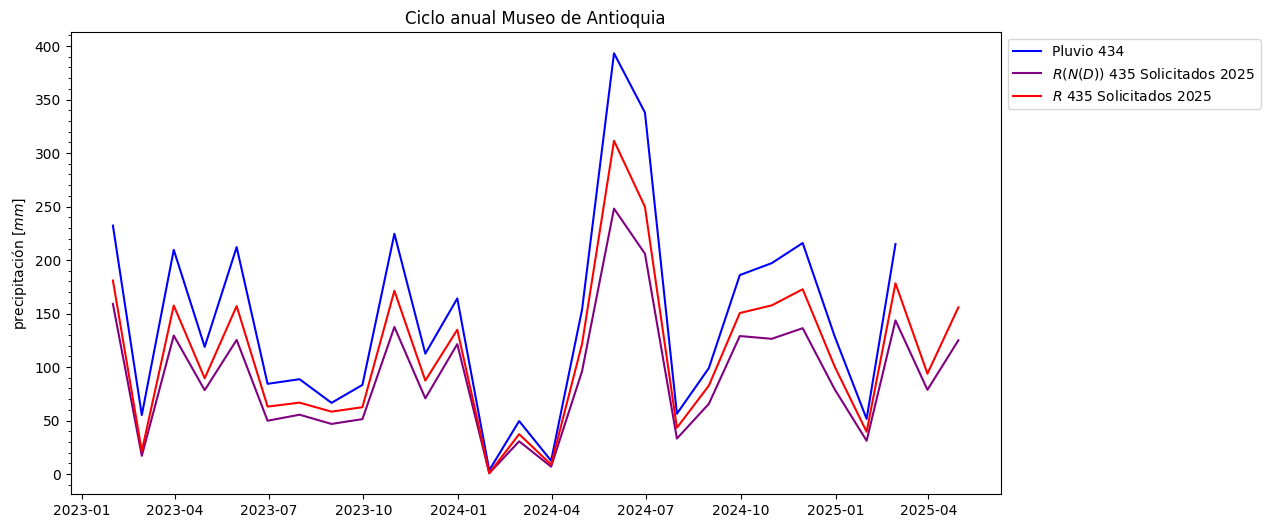

In [ ]:
plt.figure(figsize=(12, 6))
plt.title(f'Ciclo anual {Dis_name}')
plt.plot(monthly_r_g.loc[slice('2023','2025')], label=f'Pluvio {Pluvio}', color='blue')
# plt.plot(monthly_r_int_2023.loc[slice('2019','2021')], label=f'$R(N(D))$ {Disdro} Solicitados 2023', color='green')
plt.plot(monthly_r_int_2025.loc[slice('2023','2025')], label=f'$R(N(D))$ {Disdro} Solicitados 2025', color='purple')
plt.plot(R.loc[slice('2023','2025')], label=f'$R$ {Disdro} Solicitados 2025', color='Red')

plt.ylabel('precipitación $[mm]$')

# Configurar minor ticks
plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.legend()

plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')

plt.show()

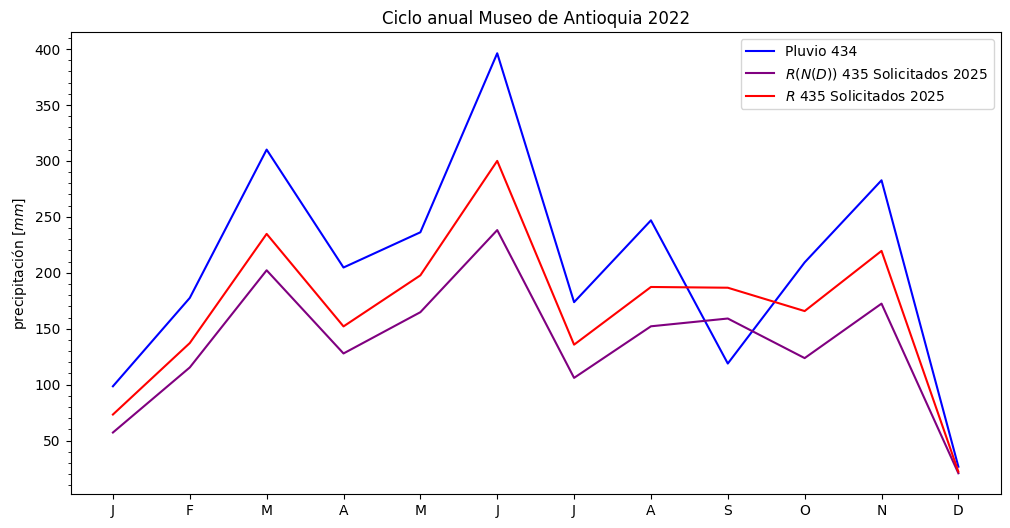

In [7]:
Year = 2022

plt.figure(figsize=(12, 6))
plt.title(f'Ciclo anual {Dis_name} {Year}')

plt.plot(x, monthly_r_g.loc[f'{Year}'], label=f'Pluvio {Pluvio}', color='blue')
# plt.plot(x, monthly_r_int_2023.loc[f'{Year}'], label=f'$R(N(D))$ {Disdro} Solicitados 2023', color='green')
plt.plot(x, monthly_r_int_2025.loc[f'{Year}'], label=f'$R(N(D))$ {Disdro} Solicitados 2025', color='purple')
plt.plot(x, R.loc[f'{Year}'], label=f'$R$ {Disdro} Solicitados 2025', color='Red')


plt.ylabel('precipitación $[mm]$')

# Configurar los ejes
plt.xticks(x, months)

# Configurar minor ticks
plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.legend()

plt.show()

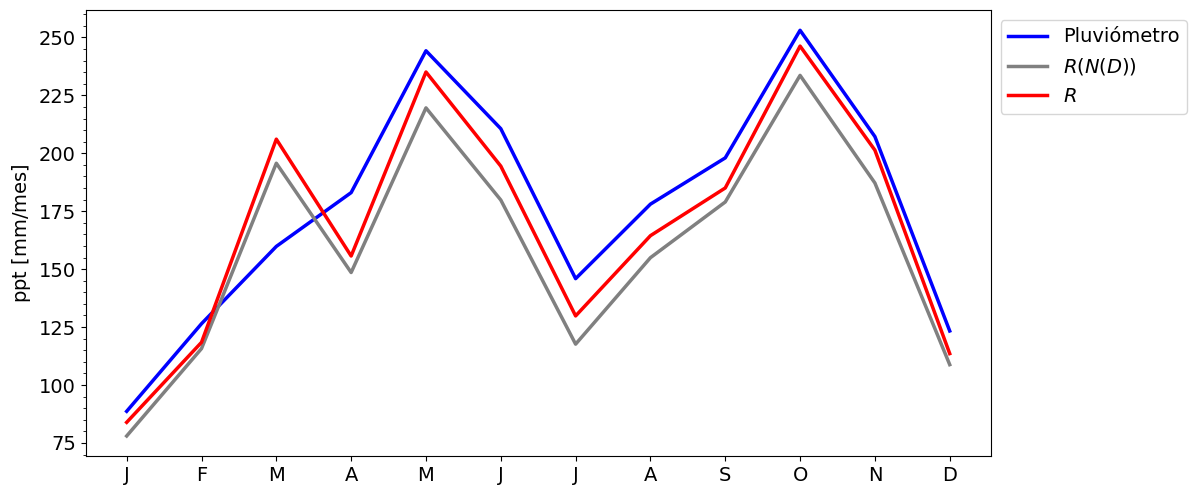

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(x, mean_monthly_r_g.values, label=f'Pluviómetro', color='blue', linewidth=2.5)
# plt.plot(x, mean_monthly_r_int_2023, label=f'$R(N(D))$ {Disdro} Solicitados 2023', color='green')
plt.plot(x, mean_monthly_r_int_2025, label=f'$R(N(D))$', color='gray', linewidth=2.5)
plt.plot(x, R_mean, label=f'$R$', color='Red', linewidth=2.5)
# plt.plot(x, Chuscal_El, label='Chuscal El', color='orange')

# plt.title(f'Promedio ciclo anual {Dis_name}')
# plt.xlabel('Mes')
plt.ylabel(r'ppt $[\text{mm/mes}]$', fontsize=14)
# plt.grid(True)
# plt.xticks(rotation=45)
plt.tight_layout()

# Configurar los ejes
plt.xticks(x, months, fontsize=14)
plt.yticks(fontsize=14)

# plt.text(0, 200, 'a)', fontsize=14, color='black')

# Configurar minor ticks
plt.gca().yaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=14)
# plt.legend()
plt.savefig(instrument_path / "Montañita_San_Antonio_Annual_Cycle.png", 
            dpi=300, 
            bbox_inches='tight')

plt.show()

Error en el promedio del ciclo anual

In [46]:
# mean_monthly_r_g = np.array([...])          # pluviómetro (referencia)
# mean_monthly_r_int_2025 = np.array([...])   # disdrómetro
# mean_monthly_r_int_2025 R(N(D)) & r_mean R

print('R(N(D))')
print()
# MAE
mae = np.mean(np.abs(mean_monthly_r_int_2025 - mean_monthly_r_g))

# RMSE
rmse = np.sqrt(np.mean((mean_monthly_r_int_2025 - mean_monthly_r_g) ** 2))

# Bias
bias = np.mean(mean_monthly_r_int_2025 - mean_monthly_r_g)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Bias: {bias:.3f}")

print()
print('R')
print()

# MAE
mae_R = np.mean(np.abs(R_mean - mean_monthly_r_g))

# RMSE
rmse_R = np.sqrt(np.mean((R_mean - mean_monthly_r_g) ** 2))

# Bias
bias_R = np.mean(R_mean - mean_monthly_r_g)

print(f"MAE: {mae_R:.3f}")
print(f"RMSE: {rmse_R:.3f}")
print(f"Bias: {bias_R:.3f}")

R(N(D))

MAE: 22.636
RMSE: 24.062
Bias: -16.654

R

MAE: 14.740
RMSE: 18.510
Bias: -7.027


Mean, STD, Sk

In [ ]:
ds_1 = xr.open_zarr(
    DATA_PATH / "resultados" / "Zarr"/ "425_events.zarr"
)

# --- Variables de interés ---
variables = ["d_m_filt", "lwc_filt", "n_w_filt"]

# Diccionario donde guardamos resultados
resultados = {}

for var in variables:
    # Pasar a numpy y limpiar NaNs
    data = ds_1[var].to_numpy().ravel()
    data = data[~np.isnan(data)]
    
    # Caso especial: aplicar log10 a Nw antes de calcular métricas
    if var == "n_w_filt":
        data = data[data > 0]  # eliminar ceros/negativos
        data = np.log10(data)
    
    # Calcular métricas
    mean_val = np.mean(data)
    std_val  = np.std(data)
    skew_val = skew(data)

    # Guardar resultados
    resultados[var] = {
        "mean": mean_val,
        "std": std_val,
        "skewness": skew_val
    }

# Mostrar resultados
for var, vals in resultados.items():
    print(f"\nVariable: {var}")
    print(f"  Mean     = {vals['mean']:.3f}")
    print(f"  Std      = {vals['std']:.3f}")
    print(f"  Skewness = {vals['skewness']:.3f}")


Variable: d_m_filt
  Mean     = 0.950
  Std      = 0.561
  Skewness = 2.129

Variable: lwc_filt
  Mean     = 0.102
  Std      = 0.308
  Skewness = 8.349

Variable: n_w_filt
  Mean     = 3.186
  Std      = 0.652
  Skewness = -0.121


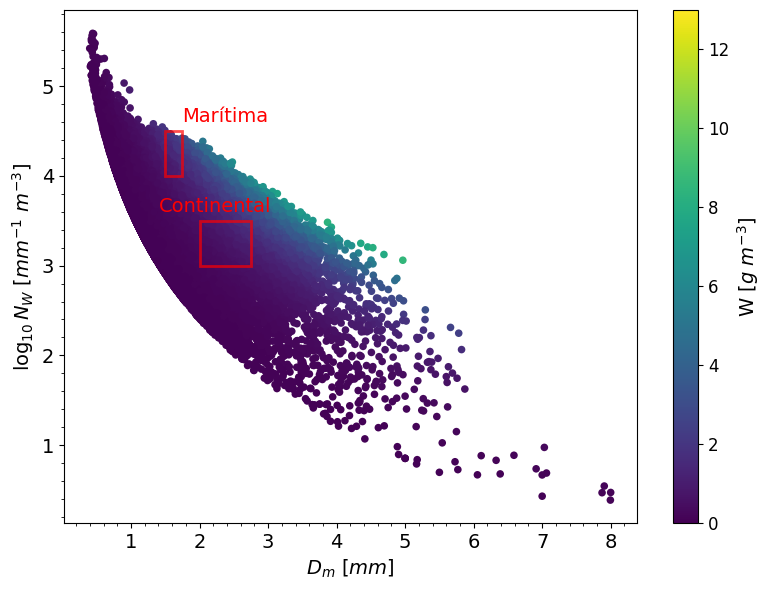

In [3]:
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Create the shape and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the scatter as a heat map
sc = ax.scatter(
    ds_JPC.d_m_filt,
    np.log10(ds_JPC.n_w_filt),
    c=ds_JPC.lwc_filt,
    cmap='viridis',
    norm=mcolors.Normalize(vmin=0, vmax=13),  # <-- rango fijo de 0 a 13
    s=30,
    edgecolors='none'
)

# --- Rectangle 1 ---
rect1 = patches.Rectangle(
    (1.5, 4),
    width=0.25,
    height=0.5,
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    alpha=0.7,
    linestyle='-'
)

# --- Rectangle 2 ---
rect2 = patches.Rectangle(
    (2, 3),
    width=0.75,
    height=0.5,
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    alpha=0.7,
    linestyle='-'
)

ax.add_patch(rect1)
ax.add_patch(rect2)

# Labels
ax.set_xlabel('$D_m\ [mm]$', fontsize=14)
ax.set_ylabel('$\log_{10}N_W\ [mm^{-1}\ m^{-3}]$', fontsize=14)
# ax.set_title('Distribución $D_m$ - $lg(N_W)$', fontsize=16)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

plt.text(1.4, 3.6, 'Continental', fontsize=14, color='red')
plt.text(1.75, 4.6, 'Marítima', fontsize=14, color='red')

# Color bar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('W $[g\ m^{-3}]$', fontsize=14)
cbar.ax.tick_params(labelsize=12)  # <-- tamaño de números del colorbar

# Layout settings
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
# plt.savefig(instrument_path / "Montañita_San_Antonio_Dm_Nw_W.png", 
#             dpi=300, 
#             bbox_inches='tight')
plt.show()


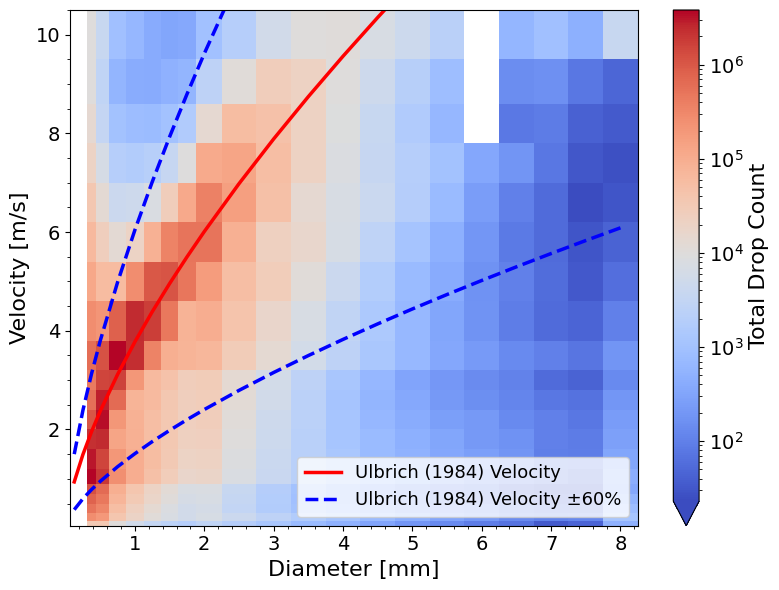

In [4]:
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Crear la figura y eje manualmente
fig, ax = plt.subplots(figsize=(8, 6))

# Sumar en el tiempo y transponer
d_v = ds_JPC.raw.sum(dim='time').T

# Crear la imagen con escala logarítmica
mesh = d_v.plot(
    ax=ax,
    norm=mcolors.LogNorm(
        vmin=d_v.where(d_v > 0).min().compute().item(), 
        vmax=d_v.max().compute().item()
    ),
    cmap='coolwarm',
    cbar_kwargs={'label': 'Conteo total de gotas'},  # título del colorbar
)

# Acceder al colorbar desde el objeto devuelto
cbar = mesh.colorbar
cbar.ax.tick_params(labelsize=14)  # ← agranda los números del colorbar
cbar.set_label('Total Drop Count', fontsize=16)  # ← agranda el texto

# Líneas de velocidad
plt.plot(ds_JPC.diameter.values, ds_JPC.vd.values, color='red', label='Ulbrich (1984) Velocity', linewidth=2.5)
plt.plot(ds_JPC.diameter.values, (ds_JPC.vd * 1.6).values, '--', color='blue', label='Ulbrich (1984) Velocity ±60%', linewidth=2.5)
plt.plot(ds_JPC.diameter.values, (ds_JPC.vd * 0.4).values, '--', color='blue', linewidth=2.5)

# Modificar los labels de los ejes
ax.set_xlabel('Diameter [mm]', fontsize=16)
ax.set_ylabel('Velocity [m/s]', fontsize=16)
# ax.set_title('Total Drop Distribution', fontsize=18)

# Tamaño de los valores numéricos de los ejes
ax.tick_params(axis='both', which='major', labelsize=14)
ax.tick_params(axis='both', which='minor', labelsize=12)

plt.legend(fontsize=13)

plt.tight_layout()
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.savefig(instrument_path / "Puerto_Triunfo_DvsV.png", 
            dpi=300, 
            bbox_inches='tight')

plt.show()
